In [1]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

import pybamm

from scr.SPMe import Solid_Phase, Cell
from scr.utils.pinn import NN_TL_Diffusion, DeepONet_TL
from scr.utils.sampling import Sampler, Sampler_DONet
from scr.utils.parameters import load_params
from scr.utils.profiles import zheng_current, constant

import numpy as np
import torch

In [1]:
param = pybamm.ParameterValues("Chen2020")
PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 1C for 100000 seconds or until 3 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1)

t = solution["Time [s]"].entries

V = solution["Terminal voltage [V]"].entries

plt.figure()
plt.grid()
plt.plot(t / 3600. * 0.5 * 5., V, "k-", label="%100 eps_p")
plt.ylim([2.5, 4.3])
plt.xlabel("Disch. Capacity [Ah]")
plt.ylabel("V [V]")

param = pybamm.ParameterValues("Chen2020")
param["Positive electrode active material volume fraction"] *= 0.9

PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 1C for 100000 seconds or until 3 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1)

t = solution["Time [s]"].entries

V = solution["Terminal voltage [V]"].entries


plt.plot(t / 3600. * 0.5 * 5., V, "b-", label="%90 eps_p")
plt.ylim([3, 4.3])
plt.legend()
plt.xlabel("Disch. Capacity [Ah]")
plt.ylabel("V [V]")
plt.show()

NameError: name 'pybamm' is not defined

In [12]:
V

array([4.10954675, 4.05679273, 4.03818478, 4.02806834, 4.02251124,
       4.01959737, 4.01808733, 4.01710836, 4.01604696, 4.0144931 ,
       4.01220042, 4.00905172, 4.00502682, 4.00017605, 3.99459282,
       3.98839479, 3.98170863, 3.97465908, 3.96736164, 3.95991801,
       3.95241319, 3.94491569, 3.93747054, 3.93010699, 3.9228302 ,
       3.91561668, 3.90840614, 3.90108796, 3.89348759, 3.88536292,
       3.87644029, 3.86652885, 3.85570749, 3.84445507, 3.83350849,
       3.82348987, 3.81463853, 3.80684482, 3.799837  , 3.79333383,
       3.78710804, 3.78099445, 3.77487712, 3.76867522, 3.76233155,
       3.75580525, 3.74906849, 3.74210448, 3.73490702, 3.72748055,
       3.71984011, 3.7120104 , 3.70402397, 3.6959188 , 3.68773453,
       3.67950811, 3.67126929, 3.66303619, 3.65481172, 3.64658106,
       3.63831053, 3.62994832, 3.62142739, 3.61267109, 3.60360182,
       3.59415302, 3.58428363, 3.57399294, 3.56333213, 3.55240798,
       3.54137489, 3.53041511, 3.51971079, 3.50941525, 3.49963

In [2]:
def RMSELoss(yhat, y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [4]:
parameters = load_params()
pos_weights = {"PDE": 1e4, "IV": 10., "BC_Center": 1., "BC_Surf": 1e4}
neg_weights = {"PDE": 1e4, "IV": 10., "BC_Center": 1., "BC_Surf": 1e4}

# model_p = NN_TL_Diffusion(general_layers=[64, 64, 64, 64], fine_layers=[32, 32], dim_in=3, dim_int=32,
#                             dim_out=1, dropout=0.)
model_p = DeepONet_TL(branch_layers=[64, 64, 64, 64], trunk_layers=[64, 64, 64, 64], fine_layers=[32, 32],
                          dim_branch=360, dim_trunk=3, dim_int=100, dim_out=1, dropout=0.)
optimizer_p = torch.optim.Adam(model_p.parameters(), lr=0.0005)
pos_model = Solid_Phase(model_p, parameters, [1., 1., 1.], criterion=RMSELoss, electrode="pos")
# model_n = NN_TL_Diffusion(general_layers=[64, 64, 64, 64], fine_layers=[32, 32], dim_in=3, dim_int=32,
#                         dim_out=1, dropout=0.)
model_n = DeepONet_TL(branch_layers=[64, 64, 64, 64], trunk_layers=[64, 64, 64, 64], fine_layers=[32, 32],
                          dim_branch=360, dim_trunk=3, dim_int=100, dim_out=1, dropout=0.)
optimizer_n = torch.optim.Adam(model_n.parameters(), lr=0.0005)
neg_model = Solid_Phase(model_n, parameters,[1., 1., 1.], criterion=RMSELoss, electrode="neg")

PINN = Cell(pos_model, neg_model)

PINN.pos_model.load_model("../models/2024-10-09_22-25/TL_pos.pt")
PINN.neg_model.load_model("../models/2024-10-09_22-25/TL_neg.pt")

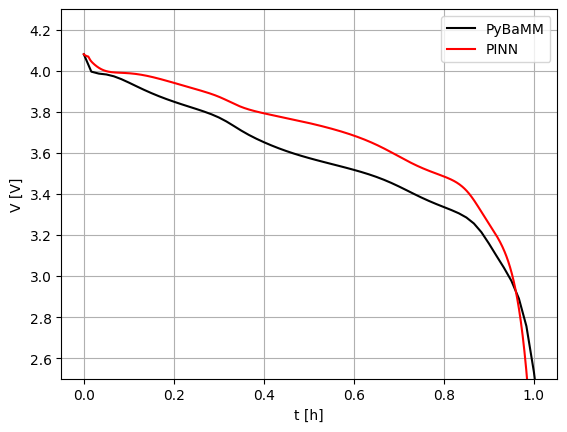

In [5]:
t_eval = np.arange(0, 3600)
cur_fun = constant(1)
PINN.pos_model.params["SOC_0"] = 1
PINN.neg_model.params["SOC_0"] = 1

bcs_sample_t = torch.linspace(0., 1., 1000)
bcs_sample_r = torch.ones_like(bcs_sample_t)
bcs_sample_I = torch.tensor(cur_fun(bcs_sample_t.numpy() * 3600.))
bcs_sample = torch.stack([bcs_sample_t, bcs_sample_r, bcs_sample_I]).t()
N = torch.tensor(cur_fun(np.arange(0., 3600, 10)))

V_pinn = PINN.compute_V((bcs_sample, N)).detach().numpy()


param = pybamm.ParameterValues("Chen2020")
PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 1C for 1000000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1.)

t = solution["Time [s]"].entries

V = solution["Terminal voltage [V]"].entries

plt.figure()
plt.grid()
plt.plot(t / 3600., V, "k-", label="PyBaMM")
plt.plot(bcs_sample_t, V_pinn, "r-", label="PINN")
plt.ylim([2.5, 4.3])
plt.xlabel("t [h]")
plt.ylabel("V [V]")
plt.legend()
plt.show()

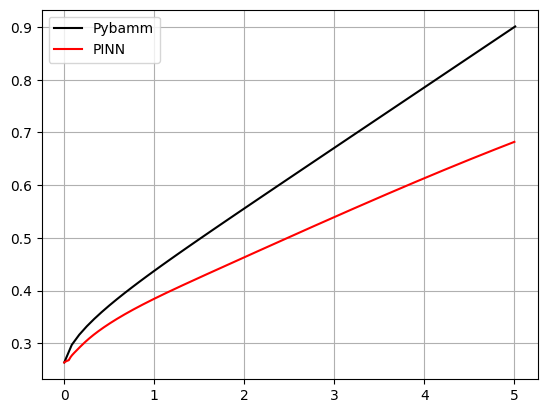

In [6]:
c_bcs = PINN.pos_model((bcs_sample, N)).detach().numpy()

c_s_p = solution["Positive particle concentration"]
r_p = solution["r_p [m]"].entries[:, 0, 0]
x = solution["x [m]"].entries[:, 0]

pos_SPM_r1 = c_s_p(r=r_p[-1], t=t, x=x[-1])

plt.figure()
plt.grid()
plt.plot(t / 3600. * 5, pos_SPM_r1, "k-",label="Pybamm")
plt.plot(bcs_sample_t.detach().numpy() * 5, c_bcs, "r-", label="PINN")
plt.legend()

In [7]:
pos_SPM_r1

array([0.26384918, 0.29719381, 0.3164812 , 0.33234811, 0.34647514,
       0.35951849, 0.37181445, 0.38356734, 0.39490531, 0.40591947,
       0.41667721, 0.42722734, 0.43760869, 0.44784994, 0.45797473,
       0.46800291, 0.47795135, 0.48783357, 0.4976603 , 0.50744082,
       0.51718297, 0.52689245, 0.53657564, 0.54623624, 0.55587772,
       0.56550295, 0.57511456, 0.58471479, 0.5943055 , 0.60388851,
       0.6134651 , 0.62303582, 0.63260252, 0.64216559, 0.6517255 ,
       0.66128273, 0.67083752, 0.68039043, 0.68994166, 0.69949144,
       0.70904004, 0.71858742, 0.72813421, 0.73768043, 0.7472262 ,
       0.75677152, 0.76631642, 0.77586106, 0.78540536, 0.79494942,
       0.80449325, 0.81403685, 0.82358036, 0.8331238 , 0.84266716,
       0.85221046, 0.86175369, 0.8712969 , 0.88084006, 0.89038317,
       0.89992623, 0.90097424])

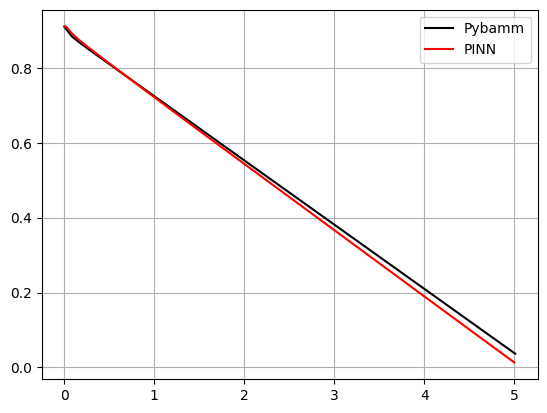

In [8]:
c_bcs = PINN.neg_model((bcs_sample, N)).detach().numpy()

c_s_n = solution["Negative particle concentration"]
r_n = solution["r_n [m]"].entries[:, 0, 0]
x = solution["x [m]"].entries[:, 0]

neg_SPM_r1 = c_s_n(r=r_n[-1], t=t, x=x[0])

plt.figure()
plt.grid()
plt.plot(t / 3600. * 5, neg_SPM_r1, "k-",label="Pybamm")
plt.plot(bcs_sample_t.detach().numpy() * 5, c_bcs, "r-", label="PINN")
plt.legend()

In [15]:
PINN.pos_model.weigths

[1.0, 1.0, 1.0]

In [8]:
V_pinn

array([4.358183 , 4.3563232, 4.3562007, 4.3581986, 4.3624334, 4.3684688,
       4.3757806, 4.383985 , 4.39241  , 4.4001045, 4.406757 , 4.412716 ,
       4.418324 , 4.4237027, 4.4288707, 4.433823 , 4.4385643, 4.443105 ,
       4.447452 , 4.4516187, 4.4556174, 4.459464 , 4.463164 , 4.4667287,
       4.4701767, 4.473507 , 4.476738 , 4.479878 , 4.4829273, 4.4858994,
       4.4887986, 4.4916263, 4.4943953, 4.497107 , 4.4997644, 4.502373 ,
       4.5049353, 4.5074577, 4.509939 , 4.5123863, 4.514797 , 4.5171776,
       4.51953  , 4.5218525, 4.5241523, 4.5264277, 4.528685 , 4.530921 ,
       4.5331445, 4.535352 , 4.537546 , 4.5397267, 4.5419016, 4.5440693,
       4.5462303, 4.548387 , 4.5505424, 4.5527005, 4.55486  , 4.557027 ,
       4.5592   , 4.5613856, 4.563583 , 4.565796 , 4.56803  , 4.5702853,
       4.5725703, 4.5748863, 4.5772367, 4.579632 , 4.582074 , 4.5845766,
       4.587139 , 4.589781 , 4.5925064, 4.5953336, 4.598277 , 4.6013675,
       4.6046185, 4.608074 , 4.611778 , 4.615787 , 

In [6]:
PINN.pos_model(bcs_sample)

NameError: name 'bcs_sample' is not defined